# Pruebas de Hipótesis: Pruebas *t* y *Z* para una Muestra

**Magíster en Ciencia de Datos e Inteligencia Artificial** · Universidad Andrés Bello
*Maidana, J.P. (2026)*

---

> *"No buscamos certezas absolutas, sino evidencia suficiente para tomar decisiones informadas."*

Versión ejecutable del apunte homónimo. Cada concepto teórico va acompañado del código `Python` que lo reproduce, de modo que puedas modificar parámetros, recalcular y visualizar resultados en vivo.

**Cómo usarlo:** ejecuta las celdas en orden (`Shift`+`Enter`). La primera celda de código carga las dependencias y debe correrse antes que el resto.

## Requisitos

- Python ≥ 3.9
- `numpy`, `scipy`, `matplotlib`

Instalación (si fuese necesario):

```bash
pip install numpy scipy matplotlib
```

In [1]:
import numpy as np
import scipy
from scipy import stats
import matplotlib.pyplot as plt

# Paleta institucional (UNAB)
NAVY, RED, GREEN = "#0d2741", "#ae0000", "#2e7d32"

plt.rcParams.update({
    "figure.figsize": (8, 4.5), "figure.dpi": 110,
    "axes.grid": True, "grid.alpha": 0.25,
    "axes.spines.top": False, "axes.spines.right": False,
    "font.size": 11,
})

print(f"numpy {np.__version__} · scipy {scipy.__version__} — entorno listo")

numpy 2.4.4 · scipy 1.17.1 — entorno listo


## 1. Introducción

### El problema de las decisiones bajo incertidumbre

Muchas decisiones reales son **binarias** y deben tomarse a partir de evidencia muestral:

| Pregunta | Decisión |
|---|---|
| ¿El peso promedio de los productos es 500 g? | ¿Aceptar o rechazar el lote? |
| ¿El nuevo medicamento reduce la presión arterial? | ¿Aprobar o rechazar el fármaco? |
| ¿El tiempo en el sitio web superó los 3 min meta? | ¿Declarar éxito o seguir optimizando? |
| ¿El nuevo proceso redujo el tiempo de producción? | ¿Implementar o mantener el proceso actual? |

> 🔑 **Pregunta central**
>
> ¿Cómo evaluar sistemáticamente si una afirmación sobre un parámetro poblacional es compatible con la evidencia observada en la muestra, **cuantificando la probabilidad de error** en la decisión?

### Intervalos de confianza vs. pruebas de hipótesis

| Aspecto | Intervalo de confianza | Prueba de hipótesis |
|---|---|---|
| Objetivo | Estimar un parámetro | Evaluar una afirmación |
| Pregunta | ¿Cuál es el valor de $\mu$? | ¿Es $\mu = \mu_0$? |
| Resultado | Rango de valores | Decisión (rechazar / no rechazar) |
| Información | Cuantitativa (magnitud) | Cualitativa (sí / no) |
| Ejemplo | "$\mu \in [48, 52]$" | "Rechazamos que $\mu = 50$" |

Ambos enfoques son **complementarios**: el IC informa sobre *magnitud*; la prueba, sobre *compatibilidad* con un valor específico.

> 📝 **Objetivos de aprendizaje**
>
> 1. Comprender la lógica de las pruebas de hipótesis (razonamiento por contradicción).
> 2. Diferenciar hipótesis nula y alternativa.
> 3. Interpretar correctamente el *p*-valor.
> 4. Distinguir errores Tipo I y Tipo II.
> 5. Dominar las pruebas *Z* y *t* de una muestra.
> 6. Implementar las pruebas en Python con `scipy.stats`.
> 7. Relacionar pruebas de hipótesis con intervalos de confianza.
> 8. Evitar errores comunes de interpretación.

## 2. Marco conceptual

> 📘 **Definición — Prueba de hipótesis**
>
> Procedimiento estadístico que usa datos muestrales para evaluar la plausibilidad de una afirmación sobre un parámetro poblacional. Sus **5 componentes** son:
>
> 1. **Hipótesis nula ($H_0$):** afirmación de "no efecto" o *status quo*; se asume verdadera hasta que la evidencia indique lo contrario. Ej. $H_0:\mu = 500$ g.
> 2. **Hipótesis alternativa ($H_1$):** contradice a $H_0$ y representa lo que se quiere demostrar. Ej. $H_1:\mu \neq 500$ g.
> 3. **Estadístico de prueba:** valor calculado de los datos que mide la evidencia contra $H_0$. Ej. $t = \dfrac{\bar{x}-\mu_0}{s/\sqrt{n}}$.
> 4. **$p$-valor:** probabilidad de observar datos tan extremos (o más) si $H_0$ fuese verdadera.
> 5. **Nivel de significancia ($\alpha$):** umbral para rechazar $H_0$ (típicamente 0.05); controla la tasa de Error Tipo I.

> 🔑 **La lógica: razonamiento por contradicción**
>
> 1. **Asumir** que $H_0$ es verdadera.
> 2. **Calcular** qué tan probable sería observar los datos bajo $H_0$.
> 3. Si esa probabilidad es **muy baja** → datos incompatibles con $H_0$ → **rechazar $H_0$**.
> 4. Si **no** es baja → datos compatibles con $H_0$ → **no rechazar $H_0$**.
>
> **Analogía jurídica:** $H_0$ = presunción de inocencia; los datos = evidencia; $\alpha$ = umbral de "duda razonable". *No rechazar* $H_0$ **no** equivale a *probar inocencia*.

> 📋 **Procedimiento general (6 pasos)**
>
> 1. Plantear $H_0$ y $H_1$.
> 2. Elegir $\alpha$.
> 3. Recolectar los datos.
> 4. Calcular el estadístico de prueba.
> 5. Calcular el $p$-valor.
> 6. Decidir: si $p \le \alpha$ → **rechazar** $H_0$; si $p > \alpha$ → **no rechazar**. Interpretar en contexto.

### Tipos de errores

| Decisión \ Realidad | $H_0$ verdadera | $H_0$ falsa |
|---|---|---|
| **No rechazar $H_0$** | ✅ Correcto ($1-\alpha$) | ❌ Error Tipo II ($\beta$, falso negativo) |
| **Rechazar $H_0$** | ❌ Error Tipo I ($\alpha$, falso positivo) | ✅ Correcto — Poder ($1-\beta$) |

> 📘 **Definición — Errores y poder**
>
> - **Error Tipo I ($\alpha$):** rechazar $H_0$ siendo verdadera (*falso positivo*). Ej. concluir que un fármaco funciona cuando no.
> - **Error Tipo II ($\beta$):** no rechazar $H_0$ siendo falsa (*falso negativo*). Ej. no detectar un efecto real.
> - **Poder estadístico ($1-\beta$):** probabilidad de detectar un efecto real. Se desea $\ge 0.80$; aumenta con mayor $n$, mayor tamaño de efecto o mayor $\alpha$.

> 🔑 **Trade-off entre errores**
>
> Con $n$ fijo: reducir $\alpha$ aumenta $\beta$ (menos poder) y viceversa. La única forma de reducir **ambos** simultáneamente es **aumentar $n$**.
>
> **Elección de $\alpha$:** 0.05 (estándar en ciencias sociales y medicina), 0.01 (conservador: física, economía), 0.10 (exploratorio). La física de partículas usa $\alpha \approx 5.7\times10^{-7}$ (5 sigma).

### Tipos de hipótesis alternativa

| Tipo | $H_0$ | $H_1$ | Cuándo usar |
|---|---|---|---|
| **Bilateral** | $\mu = \mu_0$ | $\mu \neq \mu_0$ | Detectar diferencia en cualquier dirección (más común) |
| **Unilateral >** | $\mu \le \mu_0$ | $\mu > \mu_0$ | Demostrar un aumento |
| **Unilateral <** | $\mu \ge \mu_0$ | $\mu < \mu_0$ | Demostrar una disminución |

La región de rechazo (en rojo) se ubica según $H_1$: en la prueba bilateral se reparte $\alpha/2$ en cada cola; en las unilaterales, todo $\alpha$ en una sola cola.

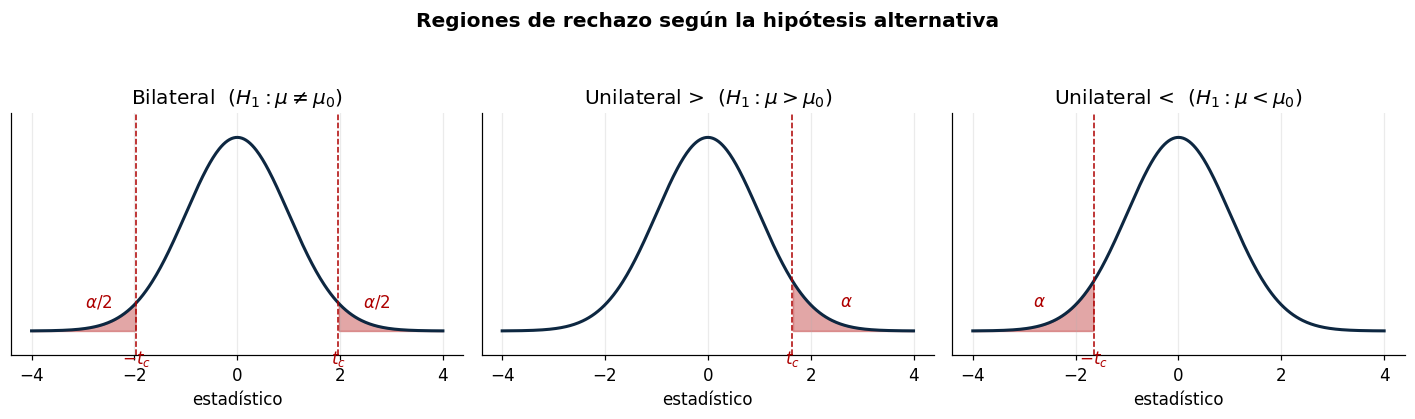

In [2]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))
x = np.linspace(-4, 4, 400)
y = stats.norm.pdf(x)
zc_bi  = stats.norm.ppf(0.975)   # ±1.96
zc_uni = stats.norm.ppf(0.95)    # 1.645

# Bilateral
ax = axes[0]
ax.plot(x, y, color=NAVY, lw=2)
ax.fill_between(x, y, where=(x <= -zc_bi), color=RED, alpha=0.35, interpolate=True)
ax.fill_between(x, y, where=(x >=  zc_bi), color=RED, alpha=0.35, interpolate=True)
for c, s in [(-zc_bi, r"$-t_c$"), (zc_bi, r"$t_c$")]:
    ax.axvline(c, color=RED, ls="--", lw=1)
    ax.text(c, -0.035, s, color=RED, ha="center", va="top")
ax.set_title(r"Bilateral  ($H_1:\mu \neq \mu_0$)")
ax.text(-2.7, 0.05, r"$\alpha/2$", color=RED, ha="center")
ax.text( 2.7, 0.05, r"$\alpha/2$", color=RED, ha="center")

# Unilateral >
ax = axes[1]
ax.plot(x, y, color=NAVY, lw=2)
ax.fill_between(x, y, where=(x >= zc_uni), color=RED, alpha=0.35, interpolate=True)
ax.axvline(zc_uni, color=RED, ls="--", lw=1)
ax.text(zc_uni, -0.035, r"$t_c$", color=RED, ha="center", va="top")
ax.set_title(r"Unilateral >  ($H_1:\mu > \mu_0$)")
ax.text(2.7, 0.05, r"$\alpha$", color=RED, ha="center")

# Unilateral <
ax = axes[2]
ax.plot(x, y, color=NAVY, lw=2)
ax.fill_between(x, y, where=(x <= -zc_uni), color=RED, alpha=0.35, interpolate=True)
ax.axvline(-zc_uni, color=RED, ls="--", lw=1)
ax.text(-zc_uni, -0.035, r"$-t_c$", color=RED, ha="center", va="top")
ax.set_title(r"Unilateral <  ($H_1:\mu < \mu_0$)")
ax.text(-2.7, 0.05, r"$\alpha$", color=RED, ha="center")

for ax in axes:
    ax.set_yticks([]); ax.set_ylim(-0.05, 0.45); ax.set_xlabel("estadístico")
fig.suptitle("Regiones de rechazo según la hipótesis alternativa",
             y=1.05, fontweight="bold")
plt.tight_layout(); plt.show()

### El p-valor

> 📘 **Definición — $p$-valor**
>
> Probabilidad de observar un estadístico tan extremo o más que el observado, **asumiendo $H_0$ verdadera**.
>
> $$\begin{aligned}
> \text{Bilateral:} &\quad p = 2\,P(|T| \ge |t_{obs}| \mid H_0)\\[2pt]
> \text{Unilateral } >:&\quad p = P(T \ge t_{obs} \mid H_0)\\[2pt]
> \text{Unilateral } <:&\quad p = P(T \le t_{obs} \mid H_0)
> \end{aligned}$$
>
> **Regla de decisión:** rechazar $H_0$ si $p \le \alpha$.

> 🔑 **Interpretación correcta del $p$-valor**
>
> **Correcto:** "si $H_0$ fuese verdadera, la probabilidad de datos tan extremos es $p$" — mide compatibilidad entre datos y $H_0$.
>
> **Incorrecto:** "probabilidad de que $H_0$ sea verdadera"; "probabilidad de que los resultados sean por azar"; "tamaño del efecto" ($p$ pequeño $\neq$ efecto grande).
>
> **Escala informal de evidencia:** $p<0.001$ (\*\*\*) muy fuerte · $p<0.01$ (\*\*) fuerte · $p<0.05$ (\*) moderada · $p<0.10$ (.) sugestiva · $p\ge0.10$ débil/nula.

## 3. Prueba *Z* para una muestra

> 📘 **Definición — Prueba *Z* para la media**
>
> **Supuestos:** muestra aleatoria; varianza poblacional $\sigma^2$ **conocida**; población normal o $n \ge 30$ (TLC).
>
> **Estadístico:**
> $$Z = \frac{\bar{x}-\mu_0}{\sigma/\sqrt{n}} \sim N(0,1)\ \text{ bajo } H_0$$
>
> **Valores críticos:** bilateral $\alpha=0.05 \Rightarrow z_c = \pm 1.96$; bilateral $\alpha=0.01 \Rightarrow \pm 2.576$; unilateral $\alpha=0.05 \Rightarrow 1.645$.

> 📋 **Procedimiento**
>
> Plantear hipótesis → elegir $\alpha$ → verificar supuestos ($\sigma$ conocida, normalidad / $n\ge30$) → calcular $Z$ → calcular $p$-valor → decidir → interpretar.

> 🧮 **Ejemplo — Control de calidad: peso de bolsas de café**
>
> **Datos:** $n=36$, $\bar{x}=497.5$ g, $\sigma=12$ g (conocida), $\mu_0=500$ g, $\alpha=0.05$, bilateral.
>
> $$SE = \frac{12}{\sqrt{36}} = 2.0,\qquad Z = \frac{497.5-500}{2.0} = -1.25$$
>
> $p = 2\,P(Z\le-1.25) = 0.211 > 0.05$ → **no rechazar $H_0$**. La diferencia de 2.5 g es compatible con la variabilidad muestral. El IC 95 % $[493.58, 501.42]$ contiene a 500, coherente con la decisión.

In [3]:
# ─── Prueba Z (varianza conocida) — ejemplo del café ───
n, x_bar, sigma, mu_0, alpha = 36, 497.5, 12.0, 500.0, 0.05

se     = sigma / np.sqrt(n)
z_stat = (x_bar - mu_0) / se
z_crit = stats.norm.ppf(1 - alpha / 2)
p_val  = 2 * stats.norm.cdf(z_stat)        # z_stat < 0 → cola izquierda ×2

print(f"SE = {se:.4f}   Z = {z_stat:.4f}   z_crit = ±{z_crit:.4f}   p = {p_val:.4f}")
decision = "RECHAZAR H0" if abs(z_stat) > z_crit else "NO RECHAZAR H0"
print(f"Decisión: {decision}")

ic = (x_bar - z_crit * se, x_bar + z_crit * se)
print(f"IC 95% = [{ic[0]:.2f}, {ic[1]:.2f}]   ¿mu_0 dentro? {ic[0] <= mu_0 <= ic[1]}")

SE = 2.0000   Z = -1.2500   z_crit = ±1.9600   p = 0.2113
Decisión: NO RECHAZAR H0
IC 95% = [493.58, 501.42]   ¿mu_0 dentro? True


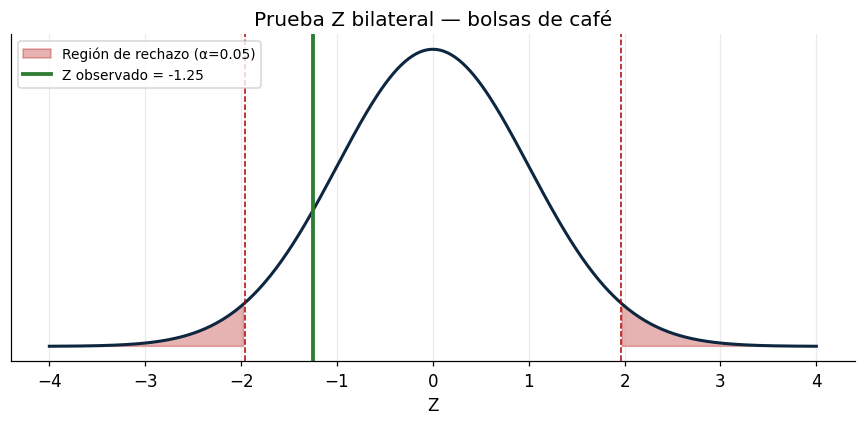

|Z| = 1.25 < 1.96  →  Z cae FUERA de la región de rechazo.


In [4]:
# Visualización de la prueba Z bilateral
fig, ax = plt.subplots(figsize=(8, 4))
x = np.linspace(-4, 4, 400)
ax.plot(x, stats.norm.pdf(x), color=NAVY, lw=2)
ax.fill_between(x, stats.norm.pdf(x), where=(np.abs(x) >= z_crit),
                color=RED, alpha=0.30, interpolate=True,
                label="Región de rechazo (α=0.05)")
ax.axvline(z_stat, color=GREEN, lw=2.5, label=f"Z observado = {z_stat:.2f}")
for c in (-z_crit, z_crit):
    ax.axvline(c, color=RED, ls="--", lw=1)
ax.set_title("Prueba Z bilateral — bolsas de café")
ax.set_xlabel("Z"); ax.set_yticks([])
ax.legend(loc="upper left", fontsize=9)
plt.tight_layout(); plt.show()

print(f"|Z| = {abs(z_stat):.2f} < {z_crit:.2f}  →  Z cae FUERA de la región de rechazo.")

## 4. Prueba *t* para una muestra

> 📘 **Definición — Prueba *t* para la media**
>
> **Supuestos:** muestra aleatoria; varianza poblacional **desconocida**; población aproximadamente normal (crítico si $n<30$) o $n \ge 30$.
>
> **Estadístico:**
> $$t = \frac{\bar{x}-\mu_0}{s/\sqrt{n}} \sim t_{\,n-1}\ \text{ bajo } H_0$$
>
> **Diferencias con la prueba *Z*:** usa la desviación estándar **muestral** $s$ en vez de $\sigma$; usa la distribución $t_{n-1}$ (colas más pesadas) en vez de $N(0,1)$; los valores críticos son mayores en muestras pequeñas, reflejando la incertidumbre extra por estimar $\sigma$.

> 🧮 **Ejemplo — Efectividad de un programa de entrenamiento**
>
> **Datos:** $n=15$, $\bar{x}\approx12.8$ puntos, $s\approx4.2$, $\mu_0=10$, $\alpha=0.05$, unilateral derecha. $H_0:\mu\le10$ vs. $H_1:\mu>10$.
>
> $$df=14,\quad SE=\frac{4.2}{\sqrt{15}}\approx1.08,\quad t=\frac{12.8-10}{1.08}\approx2.58$$
>
> $t_{0.05,14}=1.761$ y $p\approx0.011<0.05$ → **rechazar $H_0$**. Hay evidencia de que la mejora supera los 10 puntos. Tamaño del efecto: Cohen's $d=(12.8-10)/4.2\approx0.67$ (mediano-grande). La celda siguiente lo reproduce a partir de los datos crudos.

In [5]:
# ─── Prueba t (varianza desconocida) — programa de entrenamiento ───
# Datos crudos (puntos de mejora), construidos con x̄≈12.8 y s≈4.2
datos = np.array([8.3, 14.1, 2.2, 20.6, 16.4, 11.1, 11.0, 14.5,
                  11.3, 11.5, 16.8, 15.7, 12.4, 12.3, 13.7])
mu_0, alpha = 10.0, 0.05
n, x_bar, s = len(datos), datos.mean(), datos.std(ddof=1)
df = n - 1

# --- Cálculo manual (unilateral derecha) ---
se     = s / np.sqrt(n)
t_stat = (x_bar - mu_0) / se
t_crit = stats.t.ppf(1 - alpha, df)
p_uni  = 1 - stats.t.cdf(t_stat, df)

print("CÁLCULO MANUAL (H1: mu > mu_0):")
print(f"  x̄ = {x_bar:.4f}   s = {s:.4f}   SE = {se:.4f}   df = {df}")
print(f"  t = {t_stat:.4f}   t_crit = {t_crit:.4f}   p = {p_uni:.4f}")
print(f"  {'RECHAZAR H0' if t_stat > t_crit else 'NO RECHAZAR H0'}")

# --- Con scipy: ttest_1samp entrega el p bilateral; se divide entre 2 ---
t_sci, p_bil = stats.ttest_1samp(datos, mu_0)
p_unilateral = p_bil / 2
print("\nscipy.stats.ttest_1samp:")
print(f"  t = {t_sci:.4f}   p_bilateral = {p_bil:.4f}   p_unilateral = {p_unilateral:.4f}")
print(f"  {'RECHAZAR H0' if (p_unilateral < alpha and t_sci > 0) else 'NO RECHAZAR H0'}")

# --- Tamaño del efecto e IC ---
d  = (x_bar - mu_0) / s
ic = stats.t.interval(0.95, df, loc=x_bar, scale=se)
print(f"\nCohen's d = {d:.3f}   IC 95% = [{ic[0]:.2f}, {ic[1]:.2f}]")

CÁLCULO MANUAL (H1: mu > mu_0):
  x̄ = 12.7933   s = 4.1977   SE = 1.0838   df = 14
  t = 2.5773   t_crit = 1.7613   p = 0.0110
  RECHAZAR H0

scipy.stats.ttest_1samp:
  t = 2.5773   p_bilateral = 0.0219   p_unilateral = 0.0110
  RECHAZAR H0

Cohen's d = 0.665   IC 95% = [10.47, 15.12]


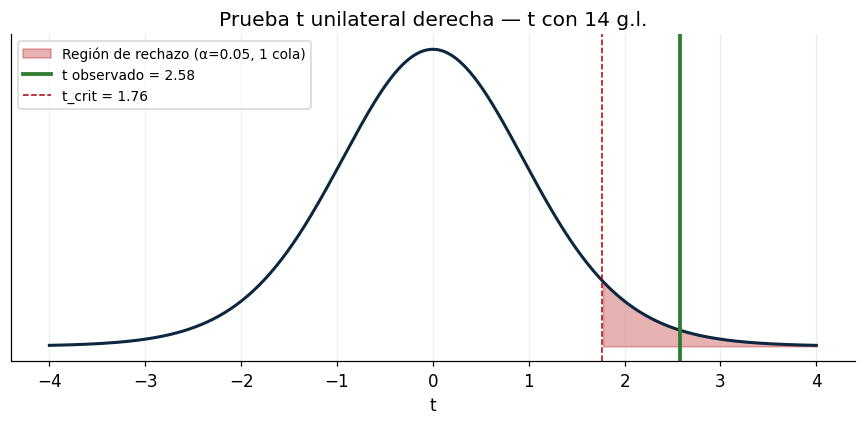

t = 2.58 > t_crit = 1.76  →  cae DENTRO de la región de rechazo (p=0.011).


In [6]:
# Visualización de la prueba t unilateral derecha
fig, ax = plt.subplots(figsize=(8, 4))
x = np.linspace(-4, 4, 400)
ax.plot(x, stats.t.pdf(x, df), color=NAVY, lw=2)
ax.fill_between(x, stats.t.pdf(x, df), where=(x >= t_crit),
                color=RED, alpha=0.30, interpolate=True,
                label="Región de rechazo (α=0.05, 1 cola)")
ax.axvline(t_stat, color=GREEN, lw=2.5, label=f"t observado = {t_stat:.2f}")
ax.axvline(t_crit, color=RED, ls="--", lw=1, label=f"t_crit = {t_crit:.2f}")
ax.set_title(f"Prueba t unilateral derecha — t con {df} g.l.")
ax.set_xlabel("t"); ax.set_yticks([])
ax.legend(loc="upper left", fontsize=9)
plt.tight_layout(); plt.show()

print(f"t = {t_stat:.2f} > t_crit = {t_crit:.2f}  →  cae DENTRO de la región de rechazo (p={p_uni:.3f}).")

### Comparación: *Z* vs. *t*

| Aspecto | Prueba *Z* | Prueba *t* |
|---|---|---|
| $\sigma$ | Conocida | Desconocida |
| Error estándar | $\sigma/\sqrt{n}$ | $s/\sqrt{n}$ |
| Distribución | $N(0,1)$ | $t_{n-1}$ |
| Valor crítico 95 % | 1.96 (fijo) | Depende de $n$ (p. ej. 2.09 si $n=20$) |
| Función `scipy` | `norm.cdf()` / `norm.ppf()` | `ttest_1samp()` |
| Cuándo usar | Raro (casi nunca) | Caso estándar |

> 🔑 **Regla práctica**
>
> En la práctica $\sigma$ casi nunca se conoce, así que **usa siempre la prueba *t* cuando $\sigma$ es desconocida** (que es prácticamente siempre). Para $n$ grande, $t \approx Z$ y no hay pérdida de precisión; para $n$ pequeño, la $t$ protege contra subestimar la incertidumbre. La prueba *Z* tiene interés principalmente **teórico**.

A continuación se ve por qué importa: con pocos grados de libertad la $t$ tiene **colas más pesadas** que la normal, y converge a ella al crecer $n$.

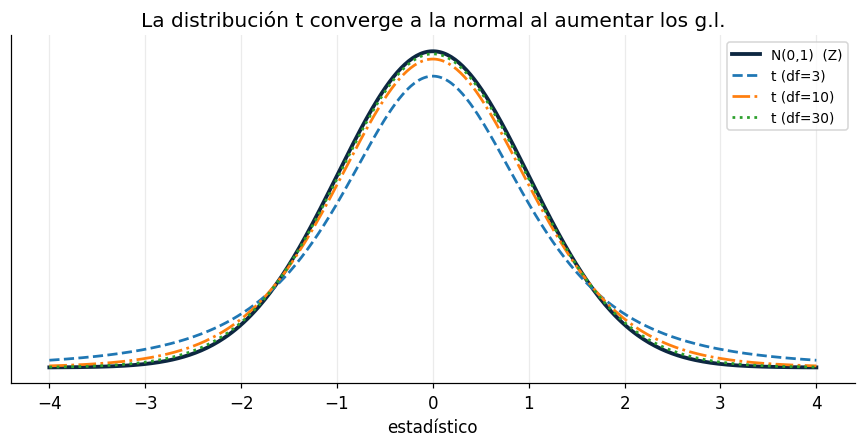

Valor crítico bilateral (95%) según los grados de libertad:
  df=  4  →  t_crit = 2.776   (Z = 1.960)
  df=  9  →  t_crit = 2.262   (Z = 1.960)
  df= 19  →  t_crit = 2.093   (Z = 1.960)
  df= 29  →  t_crit = 2.045   (Z = 1.960)
  df= 99  →  t_crit = 1.984   (Z = 1.960)


In [7]:
# La t converge a la normal al aumentar los grados de libertad
fig, ax = plt.subplots(figsize=(8, 4.2))
x = np.linspace(-4, 4, 400)
ax.plot(x, stats.norm.pdf(x), color=NAVY, lw=2.5, label="N(0,1)  (Z)")
for gl, ls in [(3, "--"), (10, "-."), (30, ":")]:
    ax.plot(x, stats.t.pdf(x, gl), ls=ls, lw=1.8, label=f"t (df={gl})")
ax.set_title("La distribución t converge a la normal al aumentar los g.l.")
ax.set_xlabel("estadístico"); ax.set_yticks([])
ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

print("Valor crítico bilateral (95%) según los grados de libertad:")
for gl in (4, 9, 19, 29, 99):
    print(f"  df={gl:3d}  →  t_crit = {stats.t.ppf(0.975, gl):.3f}   (Z = 1.960)")

## 5. Implementación en Python: función generalizada

Las celdas anteriores resolvieron los casos *Z* (manual) y *t* (con `scipy`). La siguiente función **unifica** ambos: detecta automáticamente si usar *Z* (cuando se entrega `sigma`) o *t* (cuando no), admite datos crudos o estadísticos resumidos, y maneja las tres alternativas (`two-sided`, `greater`, `less`).

In [8]:
def prueba_hipotesis_media(datos=None, x_bar=None, s=None, n=None,
                           mu_0=0, sigma=None, alpha=0.05,
                           alternativa='two-sided'):
    """
    Prueba Z (sigma conocida) o t (sigma desconocida) para la media.

    alternativa : 'two-sided' | 'greater' | 'less'
    Retorna     : dict con los resultados completos.
    """
    if datos is not None:
        datos = np.asarray(datos)
        n, x_bar, s = len(datos), datos.mean(), datos.std(ddof=1)

    if sigma is not None:                       # ── Prueba Z ──
        se   = sigma / np.sqrt(n)
        stat = (x_bar - mu_0) / se
        cdf  = stats.norm.cdf
        ppf  = stats.norm.ppf
        dist = "Z (Normal)"; df = None
    else:                                       # ── Prueba t ──
        se   = s / np.sqrt(n)
        stat = (x_bar - mu_0) / se
        df   = n - 1
        cdf  = lambda v: stats.t.cdf(v, df)
        ppf  = lambda p: stats.t.ppf(p, df)
        dist = f"t (df={df})"

    if alternativa == 'two-sided':
        p    = 2 * (1 - cdf(abs(stat)))
        vc   = ppf(1 - alpha / 2)
        rech = abs(stat) > vc
    elif alternativa == 'greater':
        p    = 1 - cdf(stat);  vc = ppf(1 - alpha);  rech = stat > vc
    else:  # 'less'
        p    = cdf(stat);      vc = ppf(alpha);      rech = stat < vc

    return {'n': n, 'media': x_bar, 'se': se, 'mu_0': mu_0,
            'estadistico': stat, 'distribucion': dist,
            'p_valor': p, 'alpha': alpha, 'valor_critico': vc,
            'rechazar_H0': rech,
            'conclusion': 'RECHAZAR H0' if rech else 'NO RECHAZAR H0'}


# ── Ejemplos ──
rng = np.random.default_rng(456)
ejemplos = [
    ("t bilateral",    dict(datos=rng.normal(105, 15, 25), mu_0=100, alternativa='two-sided')),
    ("Z unilateral >", dict(x_bar=52.5, n=100, mu_0=50, sigma=10, alternativa='greater')),
    ("t unilateral <", dict(x_bar=2.8,  s=0.6, n=50, mu_0=3.0, alternativa='less')),
]
for nombre, kwargs in ejemplos:
    r = prueba_hipotesis_media(**kwargs)
    print(f"{nombre:>16}: {r['distribucion']:>12}  "
          f"stat={r['estadistico']:6.3f}  p={r['p_valor']:.4f}  →  {r['conclusion']}")

     t bilateral:    t (df=24)  stat= 2.600  p=0.0157  →  RECHAZAR H0
  Z unilateral >:   Z (Normal)  stat= 2.500  p=0.0062  →  RECHAZAR H0
  t unilateral <:    t (df=49)  stat=-2.357  p=0.0112  →  RECHAZAR H0


## 6. Relación entre pruebas e intervalos de confianza

> 🔑 **Equivalencia: pruebas bilaterales ↔ IC**
>
> Para una prueba **bilateral** a nivel $\alpha$, son equivalentes:
>
> 1. Rechazar $H_0:\mu=\mu_0$ a nivel $\alpha$.
> 2. El IC al $(1-\alpha)\times100\%$ **no contiene** a $\mu_0$.
> 3. $|\bar{x}-\mu_0| > (\text{valor crítico})\times SE$.
>
> Un IC 95 % contiene todos los $\mu_0$ que **no** se rechazarían en una prueba bilateral al 5 %. Por eso conviene **reportar siempre el IC junto con la prueba**: añade magnitud y permite juzgar la relevancia práctica.

> 🧮 **Ejemplo de equivalencia**
>
> $n=30$, $\bar{x}=52.5$, $s=8.0$, $\mu_0=50$, $\alpha=0.05$. La prueba $t$ bilateral da $t\approx1.71$, $p\approx0.098>0.05$ → **no rechazar**. El IC 95 % $\approx[49.51, 55.49]$ **contiene** a 50, coherente con la decisión. Aunque $\bar{x}=52.5$, la evidencia es insuficiente y 50 sigue siendo plausible.

In [9]:
# Demostración numérica de la equivalencia IC ↔ prueba bilateral
n, x_bar, s, mu_0, alpha = 30, 52.5, 8.0, 50.0, 0.05
df = n - 1
se = s / np.sqrt(n)

t_stat = (x_bar - mu_0) / se
p_val  = 2 * (1 - stats.t.cdf(abs(t_stat), df))
ic     = stats.t.interval(1 - alpha, df, loc=x_bar, scale=se)
mu0_en_ic = ic[0] <= mu_0 <= ic[1]

print(f"t = {t_stat:.4f}   p = {p_val:.4f}   (α = {alpha})")
print(f"IC 95% = [{ic[0]:.2f}, {ic[1]:.2f}]")
print(f"¿mu_0 = {mu_0} dentro del IC?  {mu0_en_ic}")
print(f"Decisión por p-valor : {'NO RECHAZAR' if p_val > alpha else 'RECHAZAR'} H0")
print(f"Decisión por IC      : {'NO RECHAZAR' if mu0_en_ic else 'RECHAZAR'} H0")
print("\n→ Ambos criterios coinciden, como garantiza la equivalencia.")

t = 1.7116   p = 0.0976   (α = 0.05)
IC 95% = [49.51, 55.49]
¿mu_0 = 50.0 dentro del IC?  True
Decisión por p-valor : NO RECHAZAR H0
Decisión por IC      : NO RECHAZAR H0

→ Ambos criterios coinciden, como garantiza la equivalencia.


## 7. Errores comunes y mejores prácticas

> ⚠️ **Errores comunes**
>
> 1. **Malinterpretar el $p$-valor:** no es "la probabilidad de que $H_0$ sea verdadera", sino la probabilidad de datos tan extremos *si* $H_0$ fuese verdadera.
> 2. **Confundir significancia estadística con práctica:** con $n$ enorme, diferencias triviales resultan significativas. Reporta siempre el tamaño del efecto (Cohen's $d$).
> 3. **"Aceptar" $H_0$:** lo correcto es "no hay evidencia suficiente para rechazar $H_0$". Ausencia de evidencia $\neq$ evidencia de ausencia.
> 4. **$p$-hacking:** probar hipótesis hasta lograr $p<0.05$, o alternar bilateral/unilateral por conveniencia. Solución: predefinir el análisis y reportar todo.
> 5. **No verificar supuestos:** con $n<30$, revisar normalidad (Q–Q plot, Shapiro–Wilk); si se viola, usar transformaciones o pruebas no paramétricas.
> 6. **Tratar 0.05 como umbral mágico:** no hay diferencia real entre $p=0.049$ y $p=0.051$. Reporta el $p$-valor exacto.
> 7. **Múltiples pruebas sin corrección:** 20 pruebas generan ~1 falso positivo en promedio. Aplicar Bonferroni o FDR.

> 🔑 **Mejores prácticas**
>
> - **Planificación:** definir hipótesis y $\alpha$ antes de ver los datos; calcular poder y $n$ necesario.
> - **Supuestos:** Q–Q plot, Shapiro–Wilk ($n<50$), y documentar la verificación.
> - **Reporte completo:** hipótesis, estadístico, $df$, $p$-valor exacto, IC, tamaño del efecto, descriptivos ($n,\bar{x},s$) y conclusión en contexto.
> - **Interpretación contextual:** qué significa en el problema, no solo "rechazamos $H_0$"; distinguir asociación de causalidad.
> - **Transparencia:** reportar todos los análisis, fijar semilla, compartir código y datos.

## 8. Tabla de referencia rápida

| Concepto | Descripción / Fórmula |
|---|---|
| Hipótesis nula | $H_0:\mu=\mu_0$ |
| $H_1$ bilateral | $\mu \neq \mu_0$ |
| $H_1$ unilateral | $\mu>\mu_0$ ó $\mu<\mu_0$ |
| Estadístico $Z$ | $Z=\dfrac{\bar{x}-\mu_0}{\sigma/\sqrt{n}}\sim N(0,1)$ |
| Estadístico $t$ | $t=\dfrac{\bar{x}-\mu_0}{s/\sqrt{n}}\sim t_{n-1}$ |
| $p$ bilateral | $2\,P(|T|\ge|t_{obs}|)$ |
| $p$ unilateral > | $P(T\ge t_{obs})$ |
| $p$ unilateral < | $P(T\le t_{obs})$ |
| Decisión | Rechazar $H_0$ si $p\le\alpha$ |
| Error Tipo I ($\alpha$) | Rechazar $H_0$ verdadera (falso positivo) |
| Error Tipo II ($\beta$) | No rechazar $H_0$ falsa (falso negativo) |
| Poder | $1-\beta$ |
| Crítico $Z$ 95 % | $\pm1.96$ (bilat.), $1.645$ (unilat.) |
| Crítico $t$ 95 % | Depende de $n$ (p. ej. $\pm2.086$ si $n=20$) |
| Cohen's $d$ | $d=(\bar{x}-\mu_0)/s$ |
| `scipy` — $Z$ | `stats.norm.cdf()`, `stats.norm.ppf()` |
| `scipy` — $t$ | `stats.ttest_1samp(datos, mu_0)` |

## 9. Conclusiones

Las pruebas de hipótesis permiten decidir bajo incertidumbre evaluando afirmaciones sobre parámetros poblacionales con evidencia muestral, de forma rigurosa y cuantificable.

**Mensajes clave:**

1. **Lógica:** razonamiento por contradicción — asumir $H_0$ y evaluar compatibilidad.
2. **$p$-valor:** probabilidad de datos (o más extremos) *si* $H_0$ fuese cierta, **no** la probabilidad de $H_0$.
3. **Prueba $t$:** caso estándar cuando $\sigma$ es desconocida (casi siempre).
4. **Prueba $Z$:** solo con $\sigma$ conocida (raro en la práctica).
5. **`scipy`:** `ttest_1samp()` simplifica los cálculos.
6. **Complementar con ICs:** aportan magnitud, no solo decisión.
7. **Significancia $\neq$ importancia:** $p<0.05$ no implica un efecto grande.
8. **No "aceptar" $H_0$:** no rechazar $\neq$ demostrar que $H_0$ es verdadera.
9. **Verificar supuestos:** sobre todo normalidad con $n$ pequeño.
10. **Reportar completo:** hipótesis, estadístico, $p$-valor, IC, tamaño del efecto y conclusión contextual.

---

> 💡 **Cierre**
>
> Las pruebas de hipótesis no son un fin en sí mismas, sino una herramienta para tomar mejores decisiones. El valor no está en obtener $p<0.05$, sino en comprender qué dicen los datos sobre la realidad, cuantificar la incertidumbre y comunicar los hallazgos con rigor y honestidad.